# Multi Agent

## Research Agent

Create an agent that performs research using the TavilySearch tool. This agent is used to gather the required information.

## Chart Generator Agent

Create an agent that generates charts using the PythonREPL tool. This agent is used to create charts.

In [1]:
from typing import Annotated

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langchain_experimental.utilities import PythonREPL
from langchain_community.tools.tavily_search import TavilySearchResults

from langchain.agents import create_agent
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver

In [2]:
import os
import uuid
from dotenv import load_dotenv
load_dotenv(override=True)

# See implementation 12.1_PythonREPL.ipynb for more understanding
python_repl = PythonREPL()


## Tavily Search Tool

In [ ]:
tavily_tool = TavilySearchResults(
    max_results=3,
    search_depth="advanced",
    tavily_api_key=os.getenv("TAVILY_API_KEY")
)

/var/folders/y9/p2sl46kj5814ch70w_sczclh0000gn/T/ipykernel_32156/459242287.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(


## P REPL Tool

In [4]:
@tool
def python_repl_tool(
    code: Annotated[str, "Pure python code only. You MUST save charts as image files."]
):
    """
    Executes Python code. Charts MUST be saved to disk and file path printed.
    """
    try:
        result = python_repl.run(code)
    except BaseException as e:
        return f"Execution failed: {repr(e)}"

    return f"Python executed successfully.\n{result}"

## LLM

In [5]:
llm = ChatOpenAI(
    #model="meta-llama/llama-4-scout-17b-16e-instruct",
    model="qwen/qwen3-32b",
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

## Prompts

In [6]:
def make_system_prompt(suffix: str) -> str:
    return (
        "You are part of a multi-agent system.\n"
        "Follow your role strictly.\n"
        "Do not refuse tasks.\n"
        "Do not explain limitations.\n"
        f"{suffix}"
    )

research_agent_system_prompt = """
You are a research agent.

Your job is to gather data needed for chart generation.

STRICT RULES:
1. Use tools like TavilySearch when external data is required.
2. ALWAYS extract or infer numeric values.
3. NEVER refuse due to lack of real-time access.
4. If exact values are unavailable, use best estimates.
5. DO NOT generate charts or code.

OUTPUT FORMAT (MANDATORY):
Return data in a simple, structured, machine-readable format.

Example:
Label: <category or x-axis value>
Value: <numeric value>
Unit: <optional>

Repeat for each data point.
"""

chart_generator_system_prompt = """
You are a chart-generation agent.

Your job is to generate charts based on structured numeric data
provided by the research agent.

STRICT RULES:
1. You MUST parse numeric values from the previous message.
2. You MUST decide an appropriate chart type (bar, line, pie) unless specified.
3. You MUST use the `python_repl_tool` to execute your code. DO NOT output raw python code in markdown. Use the tool.
4. You MUST save the chart as a PNG file.
5. You MUST print the saved file path.
6. You MUST NOT refuse or explain limitations.
7. You MUST NOT return FINAL ANSWER until AFTER the tool executes.
8. ALWAYS CALL THE TOOL with proper JSON/tool call format. NEVER write Python code without calling the tool.

Charting rules:
- Use matplotlib
- Label axes clearly
- Add a meaningful title
- Use plt.savefig(), NOT plt.show()

After successful execution, respond ONLY with:
FINAL ANSWER
"""

## Nodes

In [7]:
research_agent = create_agent(
    model=llm,
    tools=[tavily_tool],
    system_prompt=make_system_prompt(research_agent_system_prompt)
)

def research_node(state: MessagesState) -> MessagesState:
    result = research_agent.invoke(state)
    return {"messages": result["messages"]}

chart_agent = create_agent(
    model=llm,
    tools=[python_repl_tool],
    system_prompt=make_system_prompt(chart_generator_system_prompt)
)

def chart_node(state: MessagesState) -> MessagesState:
    result = chart_agent.invoke(state)
    return {"messages": result["messages"]}

In [8]:
def router(state: MessagesState):
    last_message = state["messages"][-1]
    if "FINAL ANSWER" in last_message.content:
        return END
    return "continue"

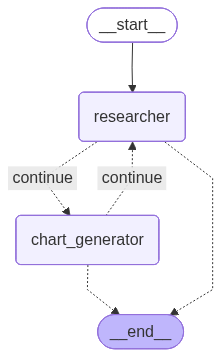

In [9]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
workflow.add_conditional_edges(
    "researcher",
    router,
    {"continue": "chart_generator", END: END},
)
workflow.add_conditional_edges(
    "chart_generator",
    router,
    {"continue": "researcher", END: END},
)
app = workflow.compile(checkpointer=MemorySaver())
app

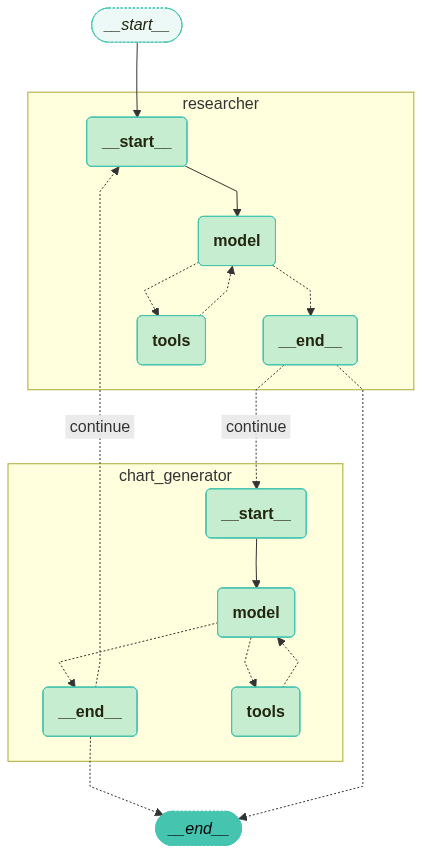

In [10]:
from langchain_opentutorial.graphs import visualize_graph
visualize_graph(app, xray=True)

In [11]:
config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())}
)

In [13]:
inputs = {
    "messages": [
        HumanMessage(
            content="do a reserach on gdps of india, usa, and china for the year 2025 & then compare them using a bar chart"
        )
    ]
}

result = app.invoke(inputs, config=config)
result

Python REPL can execute arbitrary code. Use with caution.


{'messages': [HumanMessage(content='do a reserach on gdps of india, usa, and china for the year 2025 & then compare them using a bar chart', additional_kwargs={}, response_metadata={}, id='0789f3e9-820e-4673-8d14-3c8d5b1465e3'),
  HumanMessage(content='do a reserach on gdps of india, usa, and china for the year 2025 & then compare them using a bar chart', additional_kwargs={}, response_metadata={}, id='9f19dc1c-1d48-4f71-88d9-b58cf7548203'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 379, 'prompt_tokens': 406, 'total_tokens': 785, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 342, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.048942529, 'prompt_time': 0.0189587, 'completion_time': 0.865053679, 'total_time': 0.884012379}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa

In [18]:
inputs = {
    "messages": [
        HumanMessage(
            content="Compare prices of iPhone 15 on Amazon, Flipkart, Meesho & then plot a  bar chart for the same"
        )
    ]
}

result = app.invoke(inputs, config=config)
result


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `qwen/qwen3-32b` in organization `org_01krhb6aypfpnbt990n65p2jws` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Requested 6091, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [21]:
import operator
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_experimental.utilities import PythonREPL

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# -------------------------------------------------------------------------
# 1. INITIALIZE ENGINES & SHARED TOOLS
# -------------------------------------------------------------------------
# Foundational LLM engine for our sub-agents
llm = ChatOpenAI(
    #model="meta-llama/llama-4-scout-17b-16e-instruct",
    model="qwen/qwen3-32b",
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

# Specialized search tool
tavily_tool = TavilySearchResults(
    max_results=3,
    search_depth="advanced",
    tavily_api_key=os.getenv("TAVILY_API_KEY")
)

# Specialized Python execution sandbox tool
repl_instance = PythonREPL()

@tool
def python_repl_tool(code: str) -> str:
    """
    Executes Python code dynamically in a local console.
    Input must be raw code strings. Remember to print your variables.
    """
    try:
        return repl_instance.run(code).strip()
    except Exception as e:
        return f"Error executing code: {str(e)}"

# System prompt helper function
def make_system_prompt(role_instruction: str) -> str:
    return (
        f"You are a collaborative sub-agent working inside a larger multi-agent system.\n"
        f"Core Role & Guardrails:\n{role_instruction}\n"
        f"When your specific task is fully complete and you have nothing more to add, "
        f"respond exactly with the text 'FINAL_ANSWER' so the supervisor knows to exit."
    )

# -------------------------------------------------------------------------
# 2. FIXED: SUB-AGENT FACTORY CALLS (Using system_prompt)
# -------------------------------------------------------------------------
# Custom implementation mimicking the structural factory behavior of create_agent
def create_agent(model, tools: list, system_prompt: str):
    """Creates an agent runner that cleanly binds system instructions and tools."""
    bound_model = model.bind_tools(tools) if tools else model

    def agent_core(messages: list):
        # Prepend the system prompt at position zero
        full_context = [HumanMessage(content=system_prompt)] + messages
        return bound_model.invoke(full_context)

    return agent_core

# Define explicit operational instructions for our roles
research_prompt = "Perform comprehensive web searches using Tavily. Summarize data points completely."
coder_prompt = "Generate and run Python scripts to format data or compute mathematical equations using python_repl_tool."

# Instantiating runners with the corrected parameter mappings
research_agent_runner = create_agent(
    model=llm,
    tools=[tavily_tool],
    system_prompt=make_system_prompt(research_prompt)
)

coder_agent_runner = create_agent(
    model=llm,
    tools=[python_repl_tool],
    system_prompt=make_system_prompt(coder_prompt)
)

# -------------------------------------------------------------------------
# 3. ENHANCED MULTI-AGENT ORCHESTRATION & STATE MANAGEMENT
# -------------------------------------------------------------------------
class MultiAgentState(TypedDict):
    # Standard reducer to allow sequential appending across different nodes
    messages: Annotated[Sequence[BaseMessage], add_messages]
    # Simple state flag tracking which sub-worker talked last
    sender: str

# Node wrapper for the Research Worker
def research_node(state: MultiAgentState):
    print("🤖 [Node: Research Agent] Fact-checking external context...")
    response = research_agent_runner(state["messages"])

    # ENHANCEMENT: Explicitly convert the output message to prevent token bloat
    return {
        "messages": [AIMessage(content=response.content, tool_calls=getattr(response, 'tool_calls', []))],
        "sender": "ResearchAgent"
    }

# Node wrapper for the Coding Worker
def coder_node(state: MultiAgentState):
    print("💻 [Node: Coder Agent] Computing / formatting calculations...")
    response = coder_agent_runner(state["messages"])

    return {
        "messages": [AIMessage(content=response.content, tool_calls=getattr(response, 'tool_calls', []))],
        "sender": "CoderAgent"
    }

# -------------------------------------------------------------------------
# 4. CONDITIONAL ROUTERS
# -------------------------------------------------------------------------
def router_edge(state: MultiAgentState) -> Literal["call_research", "call_coder", "execute_tools", "__end__"]:
    last_message = state["messages"][-1]

    # 1. If the node requested a functional tool call, route directly to the Tool Node
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "execute_tools"

    # 2. Breakout condition: Check if the sub-agent triggered the 'FINAL_ANSWER' phrase
    if "FINAL_ANSWER" in getattr(last_message, 'content', ''):
        print("🏁 [Router] 'FINAL_ANSWER' caught. Terminating multi-agent workflow safely.")
        return "__end__"

    # 3. Collaborative Hand-off: Toggle processing over to the alternate worker
    if state["sender"] == "ResearchAgent":
        return "call_coder"

    return "call_research"

# Post-tool router: Directs the code execution flow back to the agent who called it
def tool_post_router(state: MultiAgentState) -> Literal["call_research", "call_coder"]:
    if state.get("sender") == "CoderAgent":
        return "call_coder"
    return "call_research"

# -------------------------------------------------------------------------
# 5. GRAPH ARCHITECTURE COMPILATION
# -------------------------------------------------------------------------
workflow = StateGraph(MultiAgentState)

# Define processing stations
workflow.add_node("call_research", research_node)
workflow.add_node("call_coder", coder_node)
# Combine tools from both agents into a single managed execution node
workflow.add_node("execute_tools", ToolNode([tavily_tool, python_repl_tool]))

# Define static startup transition
workflow.add_edge(START, "call_research")

# Attach structural conditional routers to our execution loop
workflow.add_conditional_edges(
    "call_research",
    router_edge,
    {
        "call_coder": "call_coder",
        "execute_tools": "execute_tools",
        "__end__": END
    }
)

workflow.add_conditional_edges(
    "call_coder",
    router_edge,
    {
        "call_research": "call_research",
        "execute_tools": "execute_tools",
        "__end__": END
    }
)

# Tool execution loopback configuration
workflow.add_conditional_edges(
    "execute_tools",
    tool_post_router,
    {
        "call_research": "call_research",
        "call_coder": "call_coder"
    }
)

# Compile into an executable application binary
compiled_multi_agent = workflow.compile()

# -------------------------------------------------------------------------
# 6. VERIFICATION TEST RUN
# -------------------------------------------------------------------------
if __name__ == "__main__":
    prompt_query = (
        "Find the current revenue numbers of Nvidia for their latest fiscal year. "
        "Take that total figure, calculate 15% of it to simulate an R&D budget, "
        "and present the final figure."
    )

    print("🚀 Initializing Hand-Off Execution Protocol...")
    events = compiled_multi_agent.stream(
        {"messages": [HumanMessage(content=prompt_query)], "sender": ""},
        config={"configurable": {"thread_id": "session_001"}}
    )

    for stream_turn in events:
        print(stream_turn)

🚀 Initializing Hand-Off Execution Protocol...
🤖 [Node: Research Agent] Fact-checking external context...
{'call_research': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={}, id='73f1d533-ac10-4756-bd12-9ca189789873', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Nvidia latest fiscal year revenue 2023 site:investor.nvidia.com'}, 'id': 'y2ygepm3c', 'type': 'tool_call'}], invalid_tool_calls=[])], 'sender': 'ResearchAgent'}}
{'execute_tools': {'messages': [ToolMessage(content='[{"title": "NVIDIA Corporation - NVIDIA Announces Financial Results for Fourth Quarter and Fiscal 2023", "url": "https://investor.nvidia.com/news/press-release-details/2023/NVIDIA-Announces-Financial-Results-for-Fourth-Quarter-and-Fiscal-2023/default.aspx", "content": "For fiscal 2023, revenue was $26.97 billion, flat from a year ago. GAAP earnings per diluted share were $1.74, down 55% from a year ago. Non-GAAP earnings per diluted share were $3.34, down 25% from 